iEMG

sENG

sEMG (gestures 1-10)


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import scipy
import sys

sys.path.append('../Exp6 - iENG vs sENG')
import shared_iENG_sENG
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


def X_y_from_matfile(path, modality, session):
    X, y = [], []

    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'

    data_per_class_files = os.listdir(path+f'{modality}_{session}/{bluetooth_id}/raw/')

    for cls in data_per_class_files:
        input_path = path+f'{modality}_{session}/{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)

        mat = scipy.io.loadmat(input_path+files[0])
        x_tmp = mat['Data_Fea'].transpose(2, 0, 1)

        X.append(x_tmp.reshape(x_tmp.shape[0], x_tmp.shape[1]*x_tmp.shape[2]))
        y.append(mat['Data_Cls'].ravel())

    return X, y


from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

def t_sne_compute_dist(sEMG, sENG, iENG, vis=False):

    # Stack all for t-SNE
    X_all = np.vstack([sEMG, sENG, iENG])
    labels = np.array([0]*sEMG.shape[0] + [1]*sENG.shape[0] + [2]*iENG.shape[0])

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_all)

    names = ['sEMG', 'sENG', 'iENG']
    # Visualize
    if vis:
        plt.figure(figsize=(8,6))
        colors = ['r', 'g', 'b']

        for i, c, name in zip(range(3), colors, names):
            plt.scatter(X_tsne[labels==i, 0], X_tsne[labels==i, 1], c=c, label=name, alpha=0.6, s=20)

        plt.legend()
        plt.title("t-SNE of three datasets")
        plt.show()

    # Compute prototypes (mean feature vector)
    proto_i = sEMG.mean(axis=0)
    proto_s1 = sENG.mean(axis=0)
    proto_s2 = iENG.mean(axis=0)

    # Stack prototypes
    prototypes = np.vstack([proto_i, proto_s1, proto_s2])

    # Compute pairwise distances
    dist_matrix = cdist(prototypes, prototypes, metric='euclidean')
    dist_matrix = pd.DataFrame(dist_matrix, index=names, columns=names)
    #print("Pairwise distances between prototypes:\n", dist_matrix)
    return dist_matrix


from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def t_sne_compute_dist_3d(sEMG, sENG, iENG):

    # Stack all for t-SNE
    X_all = np.vstack([sEMG, sENG, iENG])
    labels = np.array([0]*sEMG.shape[0] + [1]*sENG.shape[0] + [2]*iENG.shape[0])

    # 3D t-SNE
    tsne = TSNE(n_components=3, random_state=42)
    X_tsne = tsne.fit_transform(X_all)

    # 3D Visualization
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    colors = ['r', 'g', 'b']
    names = ['sEMG', 'sENG', 'iENG']

    for i, c, name in zip(range(3), colors, names):
        ax.scatter(
            X_tsne[labels==i, 0],
            X_tsne[labels==i, 1],
            X_tsne[labels==i, 2],
            c=c, label=name, alpha=0.6, s=20
        )

    ax.set_title("3D t-SNE of three datasets")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_zlabel("t-SNE 3")
    ax.legend()
    plt.show()

    # Compute prototypes (mean feature vector)
    proto_i = sEMG.mean(axis=0)
    proto_s1 = sENG.mean(axis=0)
    proto_s2 = iENG.mean(axis=0)

    # Stack prototypes
    prototypes = np.vstack([proto_i, proto_s1, proto_s2])

    # Compute pairwise distances
    dist_matrix = cdist(prototypes, prototypes, metric='euclidean')
    dist_matrix = pd.DataFrame(dist_matrix, index=names, columns=names)

    return dist_matrix


# invasive ENG (Amputee)

In [2]:
def get_iENG():
    path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
    fname = os.listdir(path)

    iENG_subjects = {
        "subject2": {"X": [], "Y": []},
        "subject3": {"X": [], "Y": []},
    }

    for f in fname:
        for i in range(10):
            X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
            y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))
            #indices = np.random.permutation(len(X)) # shuffle
            #X, y = X[indices], y[indices]

            y_int = np.argmax(y, axis=1)
            num_classes = np.max(y_int) + 1

            if "subject2" in f:
                iENG_subjects["subject2"]["X"].append(X)
                iENG_subjects["subject2"]["Y"].append(y_int)
            elif "subject3" in f:
                iENG_subjects["subject3"]["X"].append(X)
                iENG_subjects["subject3"]["Y"].append(y_int)

    final_session = 4
    y = iENG_subjects["subject2"]['Y'][2:final_session] + iENG_subjects["subject3"]['Y'][2:final_session]
    x = iENG_subjects["subject2"]['X'][2:final_session] + iENG_subjects["subject3"]['X'][2:final_session]

    y = np.concatenate(y, axis=0)
    x = np.concatenate(x, axis=0)
    x = x.reshape(x.shape[0], 16, 14)

    x = x[:, [0, 4, 8, 12], :][:, :, [2, 4]]   # (N, 4, 5)
    x = x.reshape(x.shape[0], -1)           # (N, 20)
    # others => [0, 2, 3, 4, 12] # ZC, WL, WAMP, MAV, MAVS

    #mask = (y == 0)
    mask = (y >= 1) & (y <= 5)
    iENG_x_zero = x[mask]
    iENG_y_zero = y[mask]
    print(iENG_x_zero.shape, iENG_y_zero.shape)

    return iENG_x_zero, iENG_y_zero

# sEMG (Ninapro)

In [3]:
def get_sEMG():
    b_path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB4'

    X_lst, y_lst = [], []

    #for sub in range(10, 20):
    for sub in [1,4,5,7]:
        for rep in range(1,6):
            X = pd.read_csv(b_path+f'/Sub{sub}/Sub{sub}_Rep{rep}_data.csv')
            y = pd.read_csv(b_path+f'/Sub{sub}/Sub{sub}_Rep{rep}_label.csv')
            y = np.argmax(y, axis=1)
            mask = (y == 0)
            X = np.array(X).reshape(X.shape[0], 12, 11)
            X = X[:, [2,6,8,0], 0:2] #ninapro => [0, 1, 2, 3, 4]: MAV, WL, WAMP, ZC, MAVS
            X = X.reshape(X.shape[0], 8)
            X_lst.append(X[mask])
            y_lst.append(y[mask])

    sEMG_x_zero = np.concatenate(X_lst, axis=0)
    sEMG_y_zero = np.concatenate(y_lst, axis=0)

    print(sEMG_x_zero.shape, sEMG_y_zero.shape)
    return sEMG_x_zero, sEMG_y_zero


def get_sEMG_3DBs():
    b_path1 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB4'
    b_path2 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB5'
    b_path3 = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/DB1'

    X_lst, y_lst = [], []

    #for sub in range(10, 20):
    for sub in [1,4]:
        for rep in range(1,4):
            X = pd.read_csv(b_path1+f'/Sub{sub}/Sub{sub}_Rep{rep}_data.csv')
            y = pd.read_csv(b_path1+f'/Sub{sub}/Sub{sub}_Rep{rep}_label.csv')
            y = np.argmax(y, axis=1)
            #mask = (y == 0)
            mask = (y >= 1) & (y <= 10)
            X = np.array(X).reshape(X.shape[0], 12, 11)
            X = X[:, [2,6,8,0], 0:2] #ninapro => [0, 1, 2, 3, 4]: MAV, WL, WAMP, ZC, MAVS
            X = X.reshape(X.shape[0], 8)
            X_lst.append(X[mask])
            y_lst.append(y[mask])

    for sub in [1,4]:
        for rep in range(1,4):
            X = pd.read_csv(b_path2+f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_data.csv')
            y = pd.read_csv(b_path2+f'/Sub{sub}_serial/Sub{sub}_Rep{rep}_label.csv')
            y = np.argmax(y, axis=1)
            #mask = (y == 0)
            mask = (y >= 1) & (y <= 10)
            X = np.array(X).reshape(X.shape[0], 16, 11)
            X = X[:, [2,6,8,0], 0:2] #ninapro => [0, 1, 2, 3, 4]: MAV, WL, WAMP, ZC, MAVS
            X = X.reshape(X.shape[0], 8)
            X_lst.append(X[mask])
            y_lst.append(y[mask])

    for sub in [17,19]:
        for rep in range(1,4):
            X = pd.read_csv(b_path3+f'/Sub{sub}/Sub{sub}_Rep{rep}_data.csv')
            y = pd.read_csv(b_path3+f'/Sub{sub}/Sub{sub}_Rep{rep}_label.csv')
            y = np.argmax(y, axis=1)
            #mask = (y == 0)
            mask = (y >= 1) & (y <= 10)
            X = np.array(X).reshape(X.shape[0], 10, 11)
            X = X[:, [2,6,8,0], 0:2] #ninapro => [0, 1, 2, 3, 4]: MAV, WL, WAMP, ZC, MAVS
            X = X.reshape(X.shape[0], 8)
            X_lst.append(X[mask])
            y_lst.append(y[mask])

    sEMG_x_zero = np.concatenate(X_lst, axis=0)
    sEMG_y_zero = np.concatenate(y_lst, axis=0)

    print(sEMG_x_zero.shape, sEMG_y_zero.shape)
    return sEMG_x_zero, sEMG_y_zero

# sENG (HM, BY, MJ)

In [13]:
def get_sENG():
    bluetooth_id = 'E9AD0E7DCC2B'
    base_path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
    X_sENG_sub1, y_sENG_sub1 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Hunmin/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub2, y_sENG_sub2 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Byeongchan/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG_sub3, y_sENG_sub3 = shared_iENG_sENG.return_X_y_get_from_matfile(path = base_path+f'Minjeong/{bluetooth_id}/raw/', num_session=[0,1,2,3,4], balance=True)
    X_sENG, y_sENG = np.concatenate([X_sENG_sub1, X_sENG_sub2, X_sENG_sub3], axis=0), np.concatenate([y_sENG_sub1, y_sENG_sub2, y_sENG_sub3], axis=0)

    x, y = X_sENG, y_sENG

    #mask = (y == 0)
    mask = (y >= 1) & (y <= 5)
    sENG_x_zero = x[mask]
    sENG_y_zero = y[mask]

    sENG_x_zero = sENG_x_zero[:, :, [2, 4]]
    sENG_x_zero = sENG_x_zero.reshape(sENG_x_zero.shape[0], 8)

    print(sENG_x_zero.shape, sENG_y_zero.shape)
    return sENG_x_zero, sENG_y_zero

In [14]:
sENG_X, sENG_y = get_sENG()

(43177, 4, 14, 1) (43177,)
(43100, 4, 14, 1) (43100,)
(43228, 4, 14, 1) (43228,)
(17775, 8) (17775,)


In [15]:
iENG_X, iENG_y = get_iENG()

(24570, 8) (24570,)


In [16]:
sEMG_X, sEMG_y = get_sEMG_3DBs()

(40340, 8) (40340,)


# T-SNE

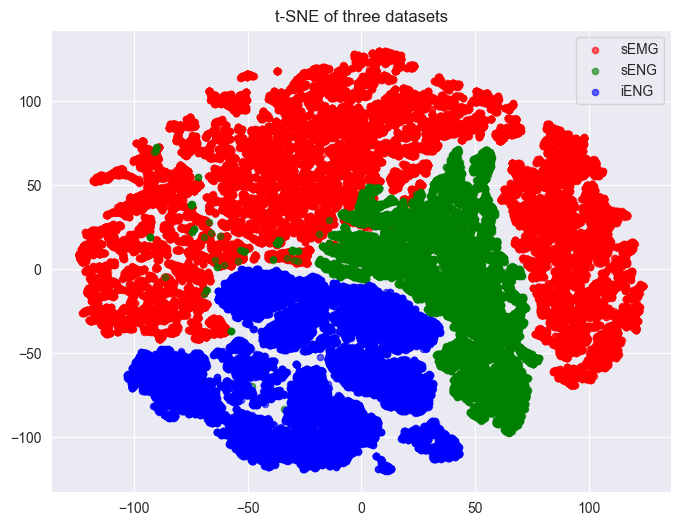

,sEMG,sENG,iENG
sEMG,0.000000,962.919336,960.980499
sENG,962.919336,0.000000,2.524274
iENG,960.980499,2.524274,0.000000


In [17]:
dist = t_sne_compute_dist(sEMG_X, sENG_X, iENG_X)
dist

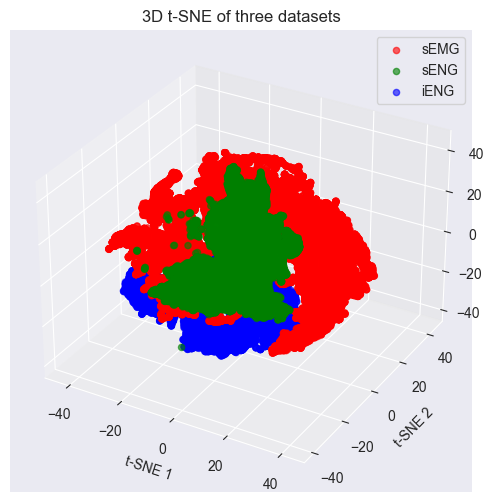

,sEMG,sENG,iENG
sEMG,0.000000,962.919336,960.980499
sENG,962.919336,0.000000,2.524274
iENG,960.980499,2.524274,0.000000


In [19]:
dist2 = t_sne_compute_dist_3d(sEMG_X, sENG_X, iENG_X)
dist2

In [20]:
960.9804988970716 + 2.5242738587400795

963.5047727558117

In [26]:
dist_all = []

for feat in range(2):
    print(sEMG_X.shape, sENG_X.shape, iENG_X.shape)
    sEMG_X = sEMG_X.reshape(sEMG_X.shape[0], 4, 2)
    sEMG_x_one_feat = sEMG_X[:, :, feat:feat+1].reshape(sEMG_X.shape[0], 4)

    sENG_X = sENG_X.reshape(sENG_X.shape[0], 4, 2)
    sENG_x_one_feat = sENG_X[:, :, feat:feat+1].reshape(sENG_X.shape[0], 4)

    iENG_X = iENG_X.reshape(iENG_X.shape[0], 4, 2)
    iENG_x_one_feat = iENG_X[:, :, feat:feat+1].reshape(iENG_X.shape[0], 4)

    print(sEMG_x_one_feat.shape, sENG_x_one_feat.shape, iENG_x_one_feat.shape)
    dist = t_sne_compute_dist(sEMG_x_one_feat, sENG_x_one_feat, iENG_x_one_feat, vis=False)

    print(dist)
    dist_all.append(dist)

(40340, 4, 2) (17775, 4, 2) (24570, 4, 2)
(40340, 4) (17775, 4) (24570, 4)
            sEMG        sENG        iENG
sEMG    0.000000  272.333396  271.149611
sENG  272.333396    0.000000    1.710866
iENG  271.149611    1.710866    0.000000
(40340, 4, 2) (17775, 4, 2) (24570, 4, 2)
(40340, 4) (17775, 4) (24570, 4)
            sEMG        sENG        iENG
sEMG    0.000000  923.606068  921.933516
sENG  923.606068    0.000000    1.856043
iENG  921.933516    1.856043    0.000000


In [ ]:
#one subject - one session
#sEMG-sENG: 6.03
#sENG-iENG: 3.84
#sEMG-iENG: 5.48


dist_df = pd.DataFrame(np.mean(dist_all, axis=0), index=['sEMG', 'sENG', 'iENG'], columns=['sEMG', 'sENG', 'iENG'])
dist_df

In [ ]:
feature_names = ['Zero Crossing (ZC)', 'Slope Sign Changes (SSC)', 'Waveform Length (WL)', 'WAMP', 'Mean Absolute Value (MAV)', 'Mean Square (MS)',
                 'Root Mean Square (RMS)', 'v-order 3 (V3)', 'log detector (LD)', 'difference absolute standard deviation value (DASDV)', 'maximum fractal length (MFL)',
                 'myopulse percentage rate (MPR)', 'mean absolute value slope (MAVS)', 'weighted mean absolute (WMS)']

dist_df = pd.DataFrame(np.mean(dist_all, axis=1), index=feature_names, columns=['sEMG', 'sENG', 'iENG'])
dist_df

In [ ]:
dist_vals = []

for f in range(14):
    sEMG_sENG = float(dist_all[f][0][1])
    sEMG_iENG = float(dist_all[f][0][2])
    sENG_iENG = float(dist_all[f][1][2])
    dist_vals.append([sEMG_sENG, sEMG_iENG, sENG_iENG])

#sns.heatmap(dist_vals, cmap='YlGnBu', fmt=)
#plt.show()
pd.DataFrame(dist_vals, columns=['sEMG-sENG', 'sEMG-iENG', 'sENG-iENG'])

1. feature-dimension
2. gesture-dimension
3.